<a href="https://colab.research.google.com/github/fahlevirafly29/Capstone-Project/blob/main/EDA_Cleaning_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Clone repository menggunakan URL HTTPS repo
!git clone https://github.com/fahlevirafly29/Capstone-Project.git

# 2. Masuk ke direktori folder (sesuaikan dengan nama folder repo)
%cd Capstone-Project

# 3. Load data menggunakan Pandas
import pandas as pd
df = pd.read_csv('dataset_after_wrangling.csv')

# Cek 5 data teratas
df.head()

Cloning into 'Capstone-Project'...
remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 13 (delta 4), reused 2 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (13/13), 13.23 MiB | 5.93 MiB/s, done.
Resolving deltas: 100% (4/4), done.
Updating files: 100% (5/5), done.
/content/Capstone-Project


,age,years_experience,education_level,major,skill_score,job,skills,certifications,projects,summary,experience_desc
0,27.214469,8.299930,master,arts,64.399443,teacher,['Teaching'],[],['teaching curriculum'],"Experienced teacher with 7 years background, p...","Involved in teaching curriculum, delivering qu..."
1,27.000514,4.407777,master,arts,79.620950,teacher,['Teaching'],[],"['mentorship program', 'workshop', 'teaching c...",I am a master graduate in arts with 4 years of...,Involved in mentorship program; workshop; teac...
2,30.875727,8.817801,bachelor,business,44.478979,data_analyst,['Excel'],['Tableau'],"['dashboard project', 'ETL pipeline', 'sales p...",With a degree in business (bachelor) and 8 yea...,Key projects: dashboard project; ETL pipeline;...
3,33.690517,13.755220,high_school,engineering,55.760838,software_engineer,"['ML', 'Python']",['Kubernetes'],"['ecommerce website', 'mobile app']",Experienced software_engineer with 14 years ba...,"Involved in ecommerce website; mobile app, del..."
4,24.256418,3.866873,master,engineering,83.029627,teacher,['Teaching'],[],"['teaching curriculum', 'workshop', 'mentorshi...",With a degree in engineering (master) and 3 ye...,Involved in teaching curriculum; workshop; men...


In [2]:
# Cek tipe data dan jumlah data non-null
df.info()

# Cek apakah ada data kosong yang tertinggal
print("Jumlah Missing Values:\n", df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285044 entries, 0 to 285043
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   age               285044 non-null  float64
 1   years_experience  285044 non-null  float64
 2   education_level   285044 non-null  object 
 3   major             285044 non-null  object 
 4   skill_score       285044 non-null  float64
 5   job               285044 non-null  object 
 6   skills            285044 non-null  object 
 7   certifications    285044 non-null  object 
 8   projects          285044 non-null  object 
 9   summary           285044 non-null  object 
 10  experience_desc   285044 non-null  object 
dtypes: float64(3), object(8)
memory usage: 23.9+ MB
Jumlah Missing Values:
 age                 0
years_experience    0
education_level     0
major               0
skill_score         0
job                 0
skills              0
certifications      0
projects    

In [14]:
# Melihat ringkasan angka untuk kolom numerik
print(df[['age', 'years_experience', 'skill_score']].describe())

# Cek apakah ada data yang tidak logis (Usia < Pengalaman)
anomali = df[df['age'] < df['years_experience']]
print(f"\nJumlah data tidak logis (Usia < Pengalaman): {len(anomali)}")


                 age  years_experience    skill_score
count  283266.000000     283266.000000  283266.000000
mean       26.814422          5.182101      65.835261
std         4.729170          4.718834      18.711191
min        18.000000          0.000000       0.000000
25%        24.000000          1.000000      53.278358
50%        27.000000          4.000000      66.317942
75%        29.000000          8.000000      79.066906
max        60.000000         29.000000     100.000000

Jumlah data tidak logis (Usia < Pengalaman): 0


In [4]:
# Menghapus data yang tidak logis
df = df[df['age'] >= df['years_experience']]
print(f"Data bersih sekarang: {len(df)} baris")

Data bersih sekarang: 285043 baris


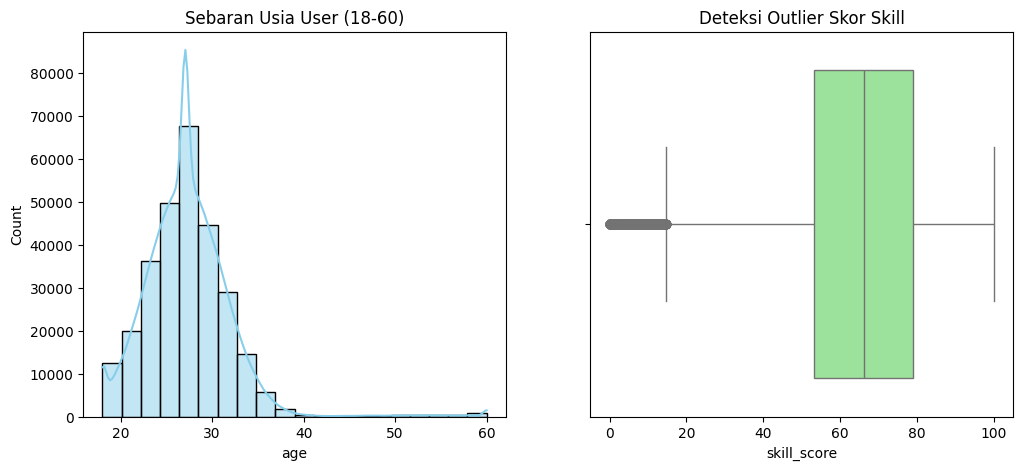

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

# Visualisasi sebaran usia
plt.subplot(1, 2, 1)
sns.histplot(df['age'], bins=20, kde=True, color='skyblue')
plt.title('Sebaran Usia User (18-60)')

# Visualisasi sebaran skor skill
plt.subplot(1, 2, 2)
sns.boxplot(x=df['skill_score'], color='lightgreen')
plt.title('Deteksi Outlier Skor Skill')

plt.show()

In [11]:
# Mengubah kolom numerik menjadi angka bulat (integer)
df['age'] = df['age'].astype(int)
df['years_experience'] = df['years_experience'].astype(int)

# Cek kembali hasilnya
df.head()

,age,years_experience,education_level,major,skill_score,job,skills,certifications,projects,summary,experience_desc
0,27,8,master,arts,64.399443,teacher,['Teaching'],[],['teaching curriculum'],"Experienced teacher with 7 years background, p...","Involved in teaching curriculum, delivering qu..."
1,27,4,master,arts,79.620950,teacher,['Teaching'],[],"['mentorship program', 'workshop', 'teaching c...",I am a master graduate in arts with 4 years of...,Involved in mentorship program; workshop; teac...
2,30,8,bachelor,business,44.478979,data_analyst,['Excel'],['Tableau'],"['dashboard project', 'ETL pipeline', 'sales p...",With a degree in business (bachelor) and 8 yea...,Key projects: dashboard project; ETL pipeline;...
3,33,13,high_school,engineering,55.760838,software_engineer,"['ML', 'Python']",['Kubernetes'],"['ecommerce website', 'mobile app']",Experienced software_engineer with 14 years ba...,"Involved in ecommerce website; mobile app, del..."
4,24,3,master,engineering,83.029627,teacher,['Teaching'],[],"['teaching curriculum', 'workshop', 'mentorshi...",With a degree in engineering (master) and 3 ye...,Involved in teaching curriculum; workshop; men...


In [12]:
# Mengubah semua kolom kategori menjadi huruf kecil agar konsisten
cols_to_fix = ['education_level', 'major', 'job']

for col in cols_to_fix:
    df[col] = df[col].str.lower().str.strip()

# Cek apakah sudah unik dan rapi
print(df['job'].unique())

['teacher' 'data_analyst' 'software_engineer' 'admin']


In [13]:
# Hanya ambil data yang logis (Usia harus lebih besar dari Pengalaman)
# Kita beri asumsi minimal mulai bekerja umur 15, jadi Age - Exp >= 15
df = df[df['age'] >= (df['years_experience'] + 15)]
print(f"Data setelah dibersihkan dari anomali: {len(df)} baris")

Data setelah dibersihkan dari anomali: 283266 baris


In [16]:
# Mengelompokkan data berdasarkan pekerjaan dan melihat statistik skor skill
skill_stats = df.groupby('job')['skill_score'].describe().sort_values(by='mean', ascending=False)
print("Statistik Skor Skill per Kategori Pekerjaan:")
print(skill_stats)

Statistik Skor Skill per Kategori Pekerjaan:
                      count       mean        std  min        25%        50%  \
job                                                                            
teacher             45044.0  72.261975  20.099152  0.0  62.061653  75.278830   
software_engineer  151955.0  68.741505  16.788795  0.0  57.501545  67.707567   
data_analyst        78459.0  59.195629  17.492326  0.0  47.182792  59.731061   
admin                7808.0  38.918741  15.520586  0.0  28.588606  38.163401   

                         75%    max  
job                                  
teacher            87.442714  100.0  
software_engineer  80.553326  100.0  
data_analyst       70.141739  100.0  
admin              48.826263  100.0  


/tmp/ipykernel_21712/105113695.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='job', y='skill_score', palette='Set2')


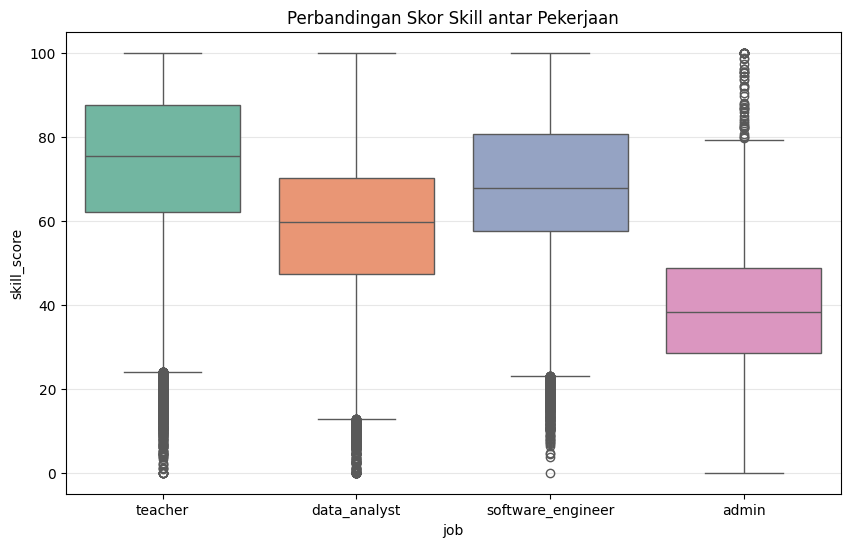

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='job', y='skill_score', palette='Set2')
plt.title('Perbandingan Skor Skill antar Pekerjaan')
plt.grid(axis='y', alpha=0.3)
plt.show()

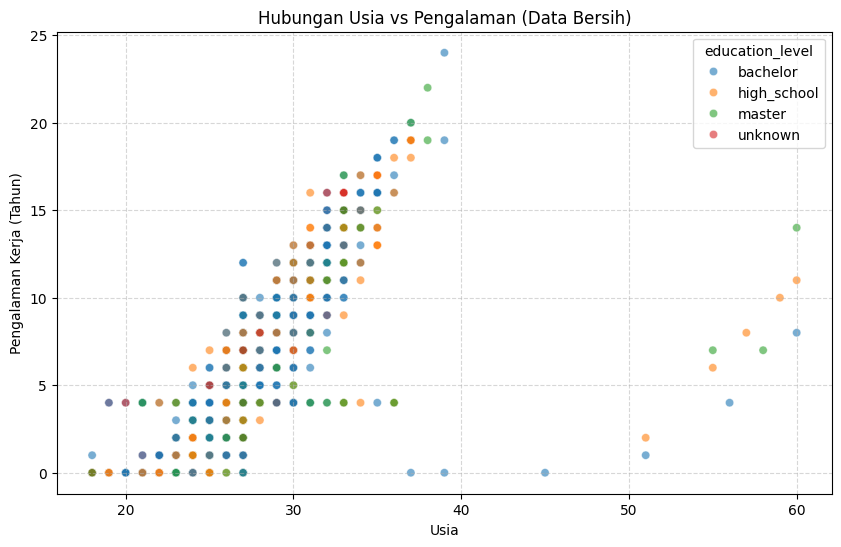

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualisasi hubungan Usia dan Pengalaman setelah dibersihkan
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df.sample(2000), x='age', y='years_experience', hue='education_level', alpha=0.6)
plt.title('Hubungan Usia vs Pengalaman (Data Bersih)')
plt.xlabel('Usia')
plt.ylabel('Pengalaman Kerja (Tahun)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [19]:
import os

# Save the cleaned DataFrame to a new CSV file
df.to_csv('dataset_cleaned_final.csv', index=False)

file_size = os.path.getsize('dataset_cleaned_final.csv') / (1024 * 1024)
print(f"Ukuran file: {file_size:.2f} MB")

Ukuran file: 82.17 MB


In [20]:
# Simpan dengan encoding utf-8 agar karakter teks aman
# index=False agar tidak menambah kolom 'Unnamed: 0' yang sering bikin risih tim AI
df.to_csv('dataset_cleaned_final.csv', index=False, encoding='utf-8')